In [258]:
import pandas as pd
from itertools import combinations
import math
import numpy as np
import statistics
from itertools import permutations
from bioinfokit import analys, visuz
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint
from matplotlib_venn import venn2
import copy
import random
from vst_function import *
from stattools.resampling import PermutationTest
from pyranges import PyRanges

# Data processing

- This notebook contains the preprocessing pipeline for both assemblies(GRCh37 and T2T-CHM13) as sames as code for table 1, figure 1 and 6. 
- Files used and saved it are located in /data folder 

## GRCh38

- These calls were obtained from HPRC in https://s3-us-west-2.amazonaws.com/human-pangenomics/index.html?prefix=submissions/759B21AD-0ED8-4640-A433-7C92A57EA3D3--UW_EEE_SV_Calls/GRCh38/
- We merge the calls using HandyCNV package in R 

In [78]:
anotation = pd.read_table('/Users/luciabazan/Downloads/biosample_table.tsv')

ids_hg19 = pd.DataFrame()
ids_hg19['Sample'] = anotation['Sample']
ids_hg19['Region'] = anotation['Superpopulation']

chm13 = pd.read_table('/Users/luciabazan/Documents/GitHub/cnv_sgdp/call_cnvr_grch38_hprc/individual_cnv_cnvr.txt')
#change to df when using telomeres and centromeres filtration


chm13 = chm13.dropna()

## Keeping only samples that are on old cnvs 
chm13 = chm13.merge(ids_hg19, right_on=['Sample'], left_on=['Sample_ID'])


#
chm13.columns = ['Chromosome', 'Start', 'End', 'CNVR_ID', 'Sample', 'CNV_start', 'CNV_end', 'CNV_Value','Length', 'Sample','Region']

#chm13 = pd.read_csv('../data/chm13_gene_regions.csv', index_col=0)
chm13['Lenght'] = chm13['End'] - chm13['Start']
chm13

## Kepp CNVs less than 1Mb and greater than 1Kb
chm13 = chm13[chm13['Lenght'] < 1000000] # 2000000
chm13 = chm13[chm13['Lenght'] > 1000]


##
### Plotiing distribution

deletions = chm13[chm13 ['CNV_Value'] < 2]
deletions['type'] = 'Deletion'
duplications = chm13[chm13['CNV_Value'] > 2]
duplications['type'] = 'Duplication'


distribution = pd.concat([deletions,duplications])

chm13.columns = ['Chromosome','Start','End','CNVR_ID,','Sample_ID','CNV_Start','CNV_End','CNV_Value','Length','Sample','Region', 'Lenght']

#change to df when using telomeres and centromeres filtration
final_cnv = chm13.pivot_table(index=["Chromosome", "Start", "End"], 
                    columns='Sample', 
                    values='CNV_Value',
                        fill_value=2).reset_index()


final_cnv['Length'] = final_cnv['End'] - final_cnv['Start']
data_grch37 = final_cnv


# Saving file for Vst and PCA 
data_grch37.to_csv('../data/input_grch38_hprc.csv')
data_grch37

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/1876964886.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deletions['type'] = 'Deletion'
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/1876964886.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplications['type'] = 'Duplication'


Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,1,65562.0,66618.0,2.0,1.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,1.000000,2.0,1.0,2.0,1.0,1056.0
1,1,96603.0,98682.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2079.0
2,1,126241.0,707779.0,1.5,1.5,1.0,1.60,1.5,1.714286,1.625,...,1.5,2.0,0.800000,1.0,1.333333,1.0,1.5,2.0,1.5,581538.0
3,1,713327.0,714478.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,1151.0
4,1,725043.0,728380.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,3337.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10568,9,138081484.0,138087539.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,0.0,2.0,2.0,6055.0
10569,9,138125044.0,138139226.0,1.0,2.0,1.0,2.00,1.5,2.000000,1.000,...,1.5,1.0,2.000000,1.0,1.000000,2.0,2.0,2.0,1.0,14182.0
10570,9,138183904.0,138186463.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2559.0
10571,9,138190962.0,138196916.0,0.0,3.0,1.5,1.50,1.0,0.000000,0.000,...,0.0,1.5,1.500000,3.0,0.000000,0.0,0.0,1.0,0.0,5954.0


In [79]:
deletions = data_grch37[(data_grch37[data_grch37.columns[3:-1]]<3).all(axis=1)]
deletions['TYPE'] = 'deletion'

duplications = data_grch37[(data_grch37[data_grch37.columns[3:-1]]>1).all(axis=1)]
duplications['TYPE'] = 'duplication'

data_grch37_input_figure= pd.concat([deletions,duplications])
data_grch37_input_figure['Length'] = data_grch37_input_figure['End'] - data_grch37_input_figure['Start']

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/1550035052.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deletions['TYPE'] = 'deletion'
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/1550035052.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplications['TYPE'] = 'duplication'


## T2T-CHM13 

- CNVs calls where obtained from HPRC in https://s3-us-west-2.amazonaws.com/human-pangenomics/index.html?prefix=submissions/759B21AD-0ED8-4640-A433-7C92A57EA3D3--UW_EEE_SV_Calls/CHM13/
- We merge the calls using HandyCNV package in R 


In [80]:
chm13 = pd.read_table('/Users/luciabazan/Documents/GitHub/cnv_sgdp/call_cnvr_t2t_hprc/individual_cnv_cnvr.txt')
#change to df when using telomeres and centromeres filtration


chm13 = chm13.dropna()

## Keeping only samples that are on old cnvs 
chm13 = chm13.merge(ids_hg19, right_on=['Sample'], left_on=['Sample_ID'])


#
chm13.columns = ['Chromosome', 'Start', 'End', 'CNVR_ID', 'Sample', 'CNV_start', 'CNV_end', 'CNV_Value','Length', 'Sample','Region']

#chm13 = pd.read_csv('../data/chm13_gene_regions.csv', index_col=0)
chm13['Lenght'] = chm13['End'] - chm13['Start']
chm13

## Kepp CNVs less than 1Mb and greater than 1Kb
chm13 = chm13[chm13['Lenght'] < 1000000] # 2000000
chm13 = chm13[chm13['Lenght'] > 1000]


##
### Plotiing distribution

deletions = chm13[chm13 ['CNV_Value'] < 2]
deletions['type'] = 'Deletion'
duplications = chm13[chm13['CNV_Value'] > 2]
duplications['type'] = 'Duplication'


distribution = pd.concat([deletions,duplications])

chm13.columns = ['Chromosome','Start','End','CNVR_ID,','Sample_ID','CNV_Start','CNV_End','CNV_Value','Length','Sample','Region', 'Lenght']

#change to df when using telomeres and centromeres filtration
final_cnv = chm13.pivot_table(index=["Chromosome", "Start", "End"], 
                    columns='Sample', 
                    values='CNV_Value',
                        fill_value=2).reset_index()

final_cnv['Length'] = final_cnv['End'] - final_cnv['Start']

data_chm13  = final_cnv


# Saving file for Vst and PCA 
data_chm13.to_csv('../data/input_t2t_hprc.csv')
data_chm13 

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/335520766.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deletions['type'] = 'Deletion'
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/335520766.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplications['type'] = 'Duplication'


Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,1,736.0,3272.0,1.0,2.0,2.000000,1.0,2.000000,1.0,1.0,...,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2536.0
1,1,24123.0,26129.0,1.0,2.0,2.000000,1.5,1.000000,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,2.0,2006.0
2,1,34674.0,134000.0,2.0,2.0,1.333333,1.0,1.444444,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,99326.0
3,1,139890.0,140991.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1101.0
4,1,151553.0,153659.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12310,9,150493245.0,150494904.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1659.0
12311,9,150539980.0,150547555.0,1.0,2.0,2.000000,2.0,1.000000,2.0,0.0,...,1.0,2.0,2.0,2.0,2.0,0.0,2.0,1.0,0.0,7575.0
12312,9,150547891.0,150549071.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1180.0
12313,9,150549961.0,150551513.0,2.0,2.0,2.000000,0.0,1.000000,2.0,2.0,...,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1552.0


In [81]:
data_chm13['Chromosome'] = 'chr' + data_chm13['Chromosome'].astype(str)

In [82]:
deletions = data_chm13[(data_chm13[data_chm13.columns[4:-1]]<3).all(axis=1)]
deletions['TYPE'] = 'deletion'

duplications = data_chm13[(data_chm13[data_chm13.columns[4:-1]]>1).all(axis=1)]
duplications['TYPE'] = 'duplication'

data_chm13_input_figure = pd.concat([deletions,duplications])
data_chm13_input_figure['Length'] = data_chm13_input_figure['End'] - data_chm13_input_figure['Start']

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/4048489117.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deletions['TYPE'] = 'deletion'
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/4048489117.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplications['TYPE'] = 'duplication'


<h1> Figure 1 

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/1144442090.py:16: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim([0, 1000000])
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/1144442090.py:27: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim([0, 1000000])


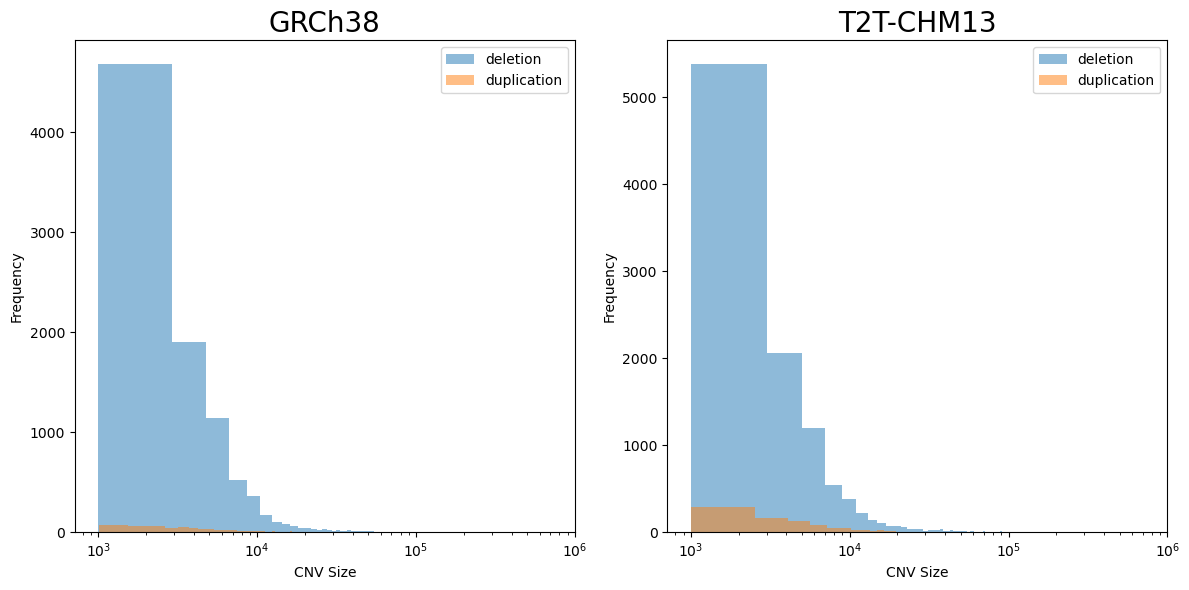

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2,  sharex=True) #sharey=True,
#ax1.set_ylim([0, 50000])

fig.set_size_inches(12, 6, forward=True)

ax1.set_title('GRCh38', size=20)


df = data_grch37_input_figure.groupby(['TYPE'])['Length']


df.plot(kind='hist',stacked=True, bins=500, logx=True, ax=ax1, alpha=0.5, legend=True) # alpha for transparency
ax1.set_xlabel('CNV Size', size=10)
ax1.set_ylabel('Frequency', size = 10)

ax1.set_xlim([0, 1000000])
#fig.suptitle
ax2.set_title('T2T-CHM13', size=20)



df = data_chm13_input_figure.groupby(['TYPE'])['Length']

df.plot(kind='hist',stacked=True, bins=500,logx=True, ax=ax2, alpha=0.5, legend=True) # alpha for transparency
ax2.set_xlabel('CNV Size', size = 10)
#ax2.set_ylabel(' ')
ax2.set_xlim([0, 1000000])
fig.tight_layout() 

#plt.savefig('../plots/distribution_t2t_and_grch37.png', transparent=True)

plt.show()

<h2> Table 1
<h3> T2T-CHM13

In [198]:
## Anotations
t2t_genes = pd.read_csv('../data/annotation_files/T2T-chm13-catLiftOffGenes.csv')
t2t_genes.columns = ['Chromosome', 'Start', 'End', 'name', 'score', 'strand',
       'thickStart', 'thickEnd', 'reserved', 'blockCount', 'blockSizes',
       'chromStarts', 'name2', 'cdsStartStat', 'cdsEndStat', 'exonFrames',
       'txId', 'type', 'geneName', 'geneType', 'sourceGene',
       'sourceTranscript', 'alignmentId', 'alternativeSourceTranscripts',
       'Paralogy', 'UnfilteredParalogy', 'collapsedGeneIds',
       'collapsedGeneNames', 'frameshift', 'exonAnnotationSupport',
       'intronAnnotationSupport', 'transcriptClass', 'transcriptModes',
       'validStart', 'validStop', 'properOrf', 'extra_paralog']
#t2t_genes['Chromosome'] = t2t_genes['Chromosome'].str.replace('chr', '')
t2t_genes = PyRanges(t2t_genes)

t2t_telomeres = pd.read_csv('../data/annotation_files/chm13v2.0_telomere.bed', sep='\t', names=['Chromosome','Start', 'End'])
#t2t_telomeres['Chromosome'] = t2t_telomeres['Chromosome'].str.replace('chr', '')
t2t_sds = pd.read_csv('../data/annotation_files/chm13v2.0_SD.full.bed', sep='\t')
t2t_sds = t2t_sds[['#chr1', 'start1', 'end1']]
#t2t_sds['#chr1'] = t2t_sds['#chr1'].str.replace('chr', '')

t2t_sds.columns =['Chromosome','Start','End']

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/2246860587.py:2: DtypeWarning: Columns (23,36) have mixed types. Specify dtype option on import or set low_memory=False.
  t2t_genes = pd.read_csv('../data/annotation_files/T2T-chm13-catLiftOffGenes.csv')


In [199]:
data_chm13_ranges = PyRanges(data_chm13)
data_chm13_ranges

Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,chr1,736,3272,1.0,2.0,2.000000,1.0,2.000000,1.0,1.0,...,2.0,2.0,2.00,1.0,2.0,2.000000,2.0,2.0,2.0,2536.0
1,chr1,24123,26129,1.0,2.0,2.000000,1.5,1.000000,2.0,2.0,...,1.0,2.0,2.00,2.0,1.0,1.000000,2.0,1.0,2.0,2006.0
2,chr1,34674,134000,2.0,2.0,1.333333,1.0,1.444444,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,0.0,2.0,99326.0
3,chr1,139890,140991,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,2.0,2.0,1101.0
4,chr1,151553,153659,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,2.0,2.0,2106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12310,chr22,51136085,51158037,2.0,2.0,1.000000,1.0,1.000000,0.0,2.0,...,2.0,1.0,1.00,2.0,1.0,1.666667,1.5,1.0,1.0,21952.0
12311,chr22,51193635,51195108,2.0,2.0,2.000000,2.0,1.000000,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,2.0,2.0,1473.0
12312,chr22,51196249,51198088,2.0,2.0,2.000000,2.0,2.000000,2.0,1.5,...,2.0,2.0,1.25,2.0,1.0,2.000000,2.0,1.0,2.0,1839.0
12313,chr22,51313529,51314814,1.0,1.0,2.000000,2.0,2.000000,1.0,2.0,...,2.0,1.0,1.00,0.5,2.0,1.000000,0.0,1.0,1.0,1285.0


In [200]:
# Genes
coordinates_genes = data_chm13_ranges.nearest(t2t_genes)
coordinates_genes = coordinates_genes.as_df()
coordinates_genes = coordinates_genes[coordinates_genes['Distance'] <1 ]

In [201]:
# Telomeres
#t2t_telomeres['Chromosome'] = t2t_telomeres['Chromosome'].str.replace('chr', '')
t2t_telomeres = PyRanges(t2t_telomeres)

coordinates_telomeres = data_chm13_ranges.nearest(t2t_telomeres)
coordinates_telomeres = coordinates_telomeres.as_df()
coordinates_telomeres = coordinates_telomeres[coordinates_telomeres['Distance'] <1]

In [202]:
# SDs
t2t_sds = PyRanges(t2t_sds)
coordinates_sds = data_chm13_ranges.nearest(t2t_sds)
coordinates_sds = coordinates_sds.as_df()
coordinates_sds = coordinates_sds[coordinates_sds['Distance'] <1 ]

In [205]:
data_chm13.iloc[:,2:207].columns[1:]

Index(['HG00097', 'HG00099', 'HG00126', 'HG00128', 'HG00133', 'HG00140',
       'HG00146', 'HG00232', 'HG00235', 'HG00253',
       ...
       'NA20809', 'NA20827', 'NA20850', 'NA20870', 'NA20905', 'NA21093',
       'NA21102', 'NA21106', 'NA21110', 'NA21144'],
      dtype='object', name='Sample', length=204)

In [206]:
## Deletions
t2t_deletions = data_chm13[(data_chm13[data_chm13.iloc[:,2:207].columns[1:]]<3).all(axis=1)]
t2t_deletions.replace(2, np.nan, inplace=True)
t2t_mean_individual_deletions = t2t_deletions.iloc[:,3:207].mean()
t2t_deletions.replace(np.nan,2, inplace=True)
t2t_deletions = PyRanges(t2t_deletions)
t2t_deletions

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/2126859852.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t2t_deletions.replace(2, np.nan, inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/2126859852.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t2t_deletions.replace(np.nan,2, inplace=True)


Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,chr1,736,3272,1.0,2.0,2.000000,1.0,2.000000,1.000000,1.0,...,2.000000,2.000000,2.000000,1.0,2.000,2.0,2.0,2.000000,2.000000,2536.0
1,chr1,34674,134000,2.0,2.0,1.333333,1.0,1.444444,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,0.000000,2.000000,99326.0
2,chr1,139890,140991,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,1101.0
3,chr1,151553,153659,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,2106.0
4,chr1,156352,344468,0.5,1.0,1.000000,0.5,1.090909,0.333333,0.5,...,0.142857,0.333333,1.142857,0.0,0.625,0.8,0.5,1.142857,1.222222,188116.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10882,chr22,50942385,50944034,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,1649.0
10883,chr22,51004619,51005728,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,1109.0
10884,chr22,51193635,51195108,2.0,2.0,2.000000,2.0,1.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,1473.0
10885,chr22,51313529,51314814,1.0,1.0,2.000000,2.0,2.000000,1.000000,2.0,...,2.000000,1.000000,1.000000,0.5,2.000,1.0,0.0,1.000000,1.000000,1285.0


In [207]:
deletions_t2t_coordinates_genes = t2t_deletions.nearest(t2t_genes)
deletions_t2t_coordinates_genes = deletions_t2t_coordinates_genes.as_df()
deletions_t2t_coordinates_genes = deletions_t2t_coordinates_genes[deletions_t2t_coordinates_genes['Distance'] <1 ]
deletions_t2t_coordinates_genes.iloc[:,3:207]

,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,HG00232,HG00235,HG00253,...,NA20809,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144
0,2.0,2.0,1.333333,1.0,1.444444,2.000000,2.00,1.000,1.500000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,2.000000,2.0,2.0,0.000000,2.000000
1,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.00,2.000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,2.000000,2.0,2.0,2.000000,2.000000
2,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.00,2.000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,2.000000,2.0,2.0,2.000000,2.000000
3,0.5,1.0,1.000000,0.5,1.090909,0.333333,0.50,0.625,1.461538,0.833333,...,0.285714,0.142857,0.333333,1.142857,0.0,0.625000,0.8,0.5,1.142857,1.222222
4,2.0,1.0,1.000000,1.0,1.000000,1.750000,1.75,2.000,2.000000,2.000000,...,1.000000,2.000000,2.000000,0.000000,1.0,1.555556,2.0,2.0,2.000000,1.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10597,2.0,1.0,1.000000,2.0,2.000000,2.000000,2.00,2.000,1.000000,2.000000,...,1.000000,0.000000,2.000000,2.000000,2.0,2.000000,1.0,2.0,1.000000,1.000000
10598,1.0,0.5,2.000000,1.0,2.000000,2.000000,2.00,2.000,1.000000,2.000000,...,1.000000,1.000000,0.500000,1.000000,1.0,0.000000,2.0,2.0,1.000000,2.000000
10599,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.00,2.000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,2.000000,2.0,2.0,2.000000,2.000000
10600,2.0,2.0,2.000000,2.0,1.000000,2.000000,2.00,2.000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,2.000000,2.0,2.0,2.000000,2.000000


In [208]:
#### Genes 
deletions_t2t_coordinates_genes = t2t_deletions.nearest(t2t_genes)
deletions_t2t_coordinates_genes = deletions_t2t_coordinates_genes.as_df()
deletions_t2t_coordinates_genes = deletions_t2t_coordinates_genes[deletions_t2t_coordinates_genes['Distance'] <1 ]
# Mean CN 
deletions_t2t_coordinates_genes.replace(2, np.nan, inplace=True)
deletions_t2t_mean_individual_genes= deletions_t2t_coordinates_genes.iloc[:,3:207].mean()
deletions_t2t_coordinates_genes.replace(np.nan,2, inplace=True)


#### Telomeres
deletions_t2t_coordinates_telomeres = t2t_deletions.nearest(t2t_telomeres)
deletions_t2t_coordinates_telomeres = deletions_t2t_coordinates_telomeres.as_df()
deletions_t2t_coordinates_telomeres = deletions_t2t_coordinates_telomeres[deletions_t2t_coordinates_telomeres['Distance'] <1 ]
deletions_t2t_coordinates_telomeres
# Mean CN 
deletions_t2t_coordinates_telomeres.replace(2, np.nan, inplace=True)
deletions_t2t_mean_individual_telomeres= deletions_t2t_coordinates_telomeres.iloc[:,3:207].mean()
deletions_t2t_coordinates_telomeres.replace(np.nan,2, inplace=True)


#### SDs 
deletions_t2t_coordinates_sds = t2t_deletions.nearest(t2t_sds)
deletions_t2t_coordinates_sds = deletions_t2t_coordinates_sds.as_df()
deletions_t2t_coordinates_sds = deletions_t2t_coordinates_sds[deletions_t2t_coordinates_sds['Distance'] <1 ]
# Mean CN 
deletions_t2t_coordinates_sds.replace(2, np.nan, inplace=True)
deletions_t2t_mean_individual_sds= deletions_t2t_coordinates_sds.iloc[:,3:207].mean()
deletions_t2t_coordinates_sds.replace(np.nan,2, inplace=True)

deletions_t2t_mean_individual_sds.mean()

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/74500179.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  deletions_t2t_coordinates_genes.replace(np.nan,2, inplace=True)


0.9211211178030234

In [209]:
####### duplications 
t2t_duplications = data_chm13[(data_chm13[data_chm13.iloc[:,3:207].columns[1:]]>=2).all(axis=1)]
t2t_duplications.replace(2, np.nan, inplace=True)
t2t_mean_individual_duplications = t2t_duplications.iloc[:,3:207].mean()
t2t_duplications.replace(np.nan,2, inplace=True)
t2t_duplications  = PyRanges(t2t_duplications)
len(t2t_duplications)

t2t_mean_individual_duplications.mean()

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/864469744.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t2t_duplications.replace(2, np.nan, inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/864469744.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t2t_duplications.replace(np.nan,2, inplace=True)


3.3584700507825507

In [210]:
#### Genes 
duplications_t2t_coordinates_genes = t2t_duplications.nearest(t2t_genes)
duplications_t2t_coordinates_genes = duplications_t2t_coordinates_genes.as_df()
duplications_t2t_coordinates_genes = duplications_t2t_coordinates_genes[duplications_t2t_coordinates_genes['Distance'] <1 ]
# Mean CN 
duplications_t2t_coordinates_genes.replace(2, np.nan, inplace=True)
duplications_t2t_mean_individual_genes= duplications_t2t_coordinates_genes.iloc[:,3:207].mean()
duplications_t2t_coordinates_genes.replace(np.nan,2, inplace=True)


#### Telomeres
duplications_t2t_coordinates_telomeres = t2t_duplications.nearest(t2t_telomeres)
duplications_t2t_coordinates_telomeres = duplications_t2t_coordinates_telomeres.as_df()
duplications_t2t_coordinates_telomeres = duplications_t2t_coordinates_telomeres[duplications_t2t_coordinates_telomeres['Distance'] <1 ]
duplications_t2t_coordinates_telomeres
# Mean CN 
duplications_t2t_coordinates_telomeres.replace(2, np.nan, inplace=True)
duplications_t2t_mean_individual_telomeres= duplications_t2t_coordinates_telomeres.iloc[:,3:207].mean()
duplications_t2t_coordinates_telomeres.replace(np.nan,2, inplace=True)


#### SDs 
duplications_t2t_coordinates_sds = t2t_duplications.nearest(t2t_sds)
duplications_t2t_coordinates_sds = duplications_t2t_coordinates_sds.as_df()
duplications_t2t_coordinates_sds = duplications_t2t_coordinates_sds[duplications_t2t_coordinates_sds['Distance'] <1 ]
# Mean CN 
duplications_t2t_coordinates_sds.replace(2, np.nan, inplace=True)
duplications_t2t_mean_individual_sds= duplications_t2t_coordinates_sds.iloc[:,3:207].mean()
duplications_t2t_coordinates_sds.replace(np.nan,2, inplace=True)

duplications_t2t_mean_individual_sds.mean()


/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/3751681795.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  duplications_t2t_coordinates_genes.replace(np.nan,2, inplace=True)


3.133771929824561

<h2> GRCh38

In [246]:
data_grch37_ranges = PyRanges(data_grch37)

## Anotations
grch37_genes = pd.read_csv('/Users/luciabazan/Downloads/grch38_genes')
grch37_telomeres = pd.read_csv('/Users/luciabazan/Downloads/grch38_telomeres')
grch37_sds = pd.read_csv('/Users/luciabazan/Downloads/grch38_sds')
#grch37_sds = grch37_sds[['#chr1', 'start1', 'end1']]


grch37_telomeres.columns =['#"bin','Chromosome','Start','End', 'ix','n', 'size','type','bridge']
#t2t_sds
grch37_genes.columns = ['#"bin"', 'name', 'Chromosome', 'strand', 'Start', 'End', 'cdsStart',
       'cdsEnd', 'exonCount', 'exonStarts', 'exonEnds', 'score', 'name2',
       'cdsStartStat', 'cdsEndStat', 'exonFrames'] 
grch37_telomeres = grch37_telomeres[grch37_telomeres['type'] == 'telomere']
grch37_sds.columns = ['#"bin"', 'Chromosome', 'Start', 'End', 'name', 'score', 'strand',
       'otherChrom', 'otherStart', 'otherEnd', 'otherSize', 'uid',
       'posBasesHit', 'testResult', 'verdict', 'chits', 'ccov', 'alignfile',
       'alignL', 'indelN', 'indelS', 'alignB', 'matchB', 'mismatchB',
       'transitionsB', 'transversionsB', 'fracMatch', 'fracMatchIndel', 'jcK',
       'k2K']

data_grch37#iloc[:,2:207].columns[1:]
#grch37_deletions#.iloc[:,2:207]


Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,1,65562.0,66618.0,2.0,1.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,1.000000,2.0,1.0,2.0,1.0,1056.0
1,1,96603.0,98682.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2079.0
2,1,126241.0,707779.0,1.5,1.5,1.0,1.60,1.5,1.714286,1.625,...,1.5,2.0,0.800000,1.0,1.333333,1.0,1.5,2.0,1.5,581538.0
3,1,713327.0,714478.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,1151.0
4,1,725043.0,728380.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,3337.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10568,9,138081484.0,138087539.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,0.0,2.0,2.0,6055.0
10569,9,138125044.0,138139226.0,1.0,2.0,1.0,2.00,1.5,2.000000,1.000,...,1.5,1.0,2.000000,1.0,1.000000,2.0,2.0,2.0,1.0,14182.0
10570,9,138183904.0,138186463.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2559.0
10571,9,138190962.0,138196916.0,0.0,3.0,1.5,1.50,1.0,0.000000,0.000,...,0.0,1.5,1.500000,3.0,0.000000,0.0,0.0,1.0,0.0,5954.0


In [247]:
## Deletions 
grch37_deletions = data_grch37[(data_grch37[data_grch37.iloc[:,2:207].columns[1:]]<3).all(axis=1)]
grch37_deletions.replace(2, np.nan, inplace=True)
grch37_mean_individual_deletions = grch37_deletions.iloc[:,3:207].mean()
grch37_deletions.replace(np.nan,2, inplace=True)
grch37_deletions = PyRanges(grch37_deletions)

# duplications 
grch37_duplications = data_grch37[(data_grch37[data_grch37.iloc[:,2:207].columns[1:]]>1).all(axis=1)]
grch37_duplications.replace(2, np.nan, inplace=True)
grch37_mean_individual_duplications = grch37_duplications.iloc[:,3:207].mean()
grch37_duplications.replace(np.nan,2, inplace=True)
grch37_duplications  = PyRanges(grch37_duplications)
grch37_mean_individual_duplications.mean()

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/2992600415.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grch37_deletions.replace(2, np.nan, inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/2992600415.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grch37_deletions.replace(np.nan,2, inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_10987/2992600415.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

4.1694392460014535

In [248]:
grch37_genes['Chromosome'] = grch37_genes['Chromosome'].str.replace('chr', '')
grch37_genes_coordinates = PyRanges(grch37_genes)

In [249]:
grch37_coordinates_genes = data_grch37_ranges.nearest(grch37_genes_coordinates)
grch37_coordinates_genes = grch37_coordinates_genes.as_df()
grch37_coordinates_genes = grch37_coordinates_genes[grch37_coordinates_genes['Distance'] <1 ]
len(grch37_coordinates_genes)

5669

In [250]:
grch37_telomeres['Chromosome'] = grch37_telomeres['Chromosome'].str.replace('chr', '')
grch37_telomeres = PyRanges(grch37_telomeres)
grch37_coordinates_telomeres = data_grch37_ranges.nearest(grch37_telomeres)
grch37_coordinates_telomeres = grch37_coordinates_telomeres.as_df()
grch37_coordinates_telomeres = grch37_coordinates_telomeres[grch37_coordinates_telomeres['Distance'] <1 ]

In [251]:
grch37_sds['Chromosome'] = grch37_sds['Chromosome'].str.replace('chr', '')
grch37_sds = PyRanges(grch37_sds)
grch37_coordinates_sds = data_grch37_ranges.nearest(grch37_sds)
grch37_coordinates_sds = grch37_coordinates_sds.as_df()
grch37_coordinates_sds = grch37_coordinates_sds[grch37_coordinates_sds['Distance'] <1 ]

In [252]:
### Deletions 
#### Genes 
deletions_grch37_coordinates_genes = grch37_deletions.nearest(grch37_genes_coordinates)
deletions_grch37_coordinates_genes = deletions_grch37_coordinates_genes.as_df()
deletions_grch37_coordinates_genes = deletions_grch37_coordinates_genes[deletions_grch37_coordinates_genes['Distance'] <1 ]
# Mean CN 
deletions_grch37_coordinates_genes.replace(2, np.nan, inplace=True)
deletions_grch37_mean_individual_genes= deletions_grch37_coordinates_genes.iloc[:,3:207].mean()
deletions_grch37_coordinates_genes.replace(np.nan,2, inplace=True)


### Telomeres
deletions_grch37_coordinates_telomeres = grch37_deletions.nearest(grch37_telomeres)
deletions_grch37_coordinates_telomeres = deletions_grch37_coordinates_telomeres.as_df()
deletions_grch37_coordinates_telomeres = deletions_grch37_coordinates_telomeres[deletions_grch37_coordinates_telomeres['Distance'] <1 ]
deletions_grch37_coordinates_telomeres
# Mean CN 
deletions_grch37_coordinates_telomeres.replace(2, np.nan, inplace=True)
deletions_grch37_mean_individual_telomeres= deletions_grch37_coordinates_telomeres.iloc[:,3:207].mean()
deletions_grch37_coordinates_telomeres.replace(np.nan,2, inplace=True)


#### SDs 
deletions_grch37_coordinates_sds = grch37_deletions.nearest(grch37_sds)
deletions_grch37_coordinates_sds = deletions_grch37_coordinates_sds.as_df()
deletions_grch37_coordinates_sds = deletions_grch37_coordinates_sds[deletions_grch37_coordinates_sds['Distance'] <1 ]
# Mean CN 
deletions_grch37_coordinates_sds.replace(2, np.nan, inplace=True)
deletions_grch37_mean_individual_sds= deletions_grch37_coordinates_sds.iloc[:,3:207].mean()
deletions_grch37_coordinates_sds.replace(np.nan,2, inplace=True)



In [253]:
deletions_grch37_coordinates_genes.iloc[:,3:207]

,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,HG00232,HG00235,HG00253,...,NA20809,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144
0,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000000,2.00,2.000000,...,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.000,2.000000,2.0,2.000000
1,1.500000,1.5,1.00,1.600000,1.5,1.714286,1.625000,1.285714,1.25,1.000000,...,1.333333,1.5,2.0,0.800000,1.0,1.333333,1.000,1.500000,2.0,1.500000
2,0.000000,0.0,0.00,0.000000,0.0,0.000000,0.000000,0.000000,0.00,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000,0.000000,0.0,0.000000
3,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000000,2.00,2.000000,...,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.000,2.000000,2.0,2.000000
4,0.777778,0.0,1.00,0.333333,0.9,0.333333,0.625000,0.625000,1.10,1.000000,...,0.000000,0.5,1.0,0.888889,0.0,0.500000,0.625,0.500000,1.0,1.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9462,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000000,2.00,2.000000,...,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.000,2.000000,2.0,2.000000
9463,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000000,2.00,2.000000,...,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.000,2.000000,2.0,2.000000
9464,0.250000,0.0,0.75,1.000000,1.0,0.400000,1.333333,0.000000,1.00,0.600000,...,0.250000,1.0,1.0,0.333333,0.0,0.750000,0.000,0.500000,1.0,1.000000
9465,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000000,2.00,2.000000,...,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.000,2.000000,2.0,2.000000


In [254]:
### Duplications
#### Genes 
duplications_grch37_coordinates_genes = grch37_duplications.nearest(grch37_genes_coordinates)
duplications_grch37_coordinates_genes = duplications_grch37_coordinates_genes.as_df()
duplications_grch37_coordinates_genes = duplications_grch37_coordinates_genes[duplications_grch37_coordinates_genes['Distance'] <1 ]
# Mean CN 
duplications_grch37_coordinates_genes.replace(2, np.nan, inplace=True)
duplications_grch37_mean_individual_genes= duplications_grch37_coordinates_genes.iloc[:,3:207].mean()
duplications_grch37_coordinates_genes.replace(np.nan,2, inplace=True)


#### Telomeres
duplications_grch37_coordinates_telomeres = grch37_duplications.nearest(grch37_telomeres)
duplications_grch37_coordinates_telomeres = duplications_grch37_coordinates_telomeres.as_df()
duplications_grch37_coordinates_telomeres = duplications_grch37_coordinates_telomeres[duplications_grch37_coordinates_telomeres['Distance'] <1 ]
# Mean CN 
duplications_grch37_coordinates_telomeres.replace(2, np.nan, inplace=True)
duplications_grch37_mean_individual_telomeres= duplications_grch37_coordinates_telomeres.iloc[:,3:207].mean()
duplications_grch37_coordinates_telomeres.replace(np.nan,2, inplace=True)


#### SDs 
duplications_grch37_coordinates_sds = grch37_duplications.nearest(grch37_sds)
duplications_grch37_coordinates_sds = duplications_grch37_coordinates_sds.as_df()
duplications_grch37_coordinates_sds = duplications_grch37_coordinates_sds[duplications_grch37_coordinates_sds['Distance'] <1 ]
# Mean CN 
duplications_grch37_coordinates_sds.replace(2, np.nan, inplace=True)
duplications_grch37_mean_individual_sds= duplications_grch37_coordinates_sds.iloc[:,3:207].mean()
duplications_grch37_coordinates_sds.replace(np.nan,2, inplace=True)

In [255]:
duplications_grch37_coordinates_sds.iloc[:,3:207]

,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,HG00232,HG00235,HG00253,...,NA20809,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144
0,1.95,1.933333,1.853659,2.12,1.615385,1.826087,1.833333,1.939394,1.895833,1.902439,...,1.821429,1.875,1.826087,1.9375,1.863636,1.871795,2.0625,1.959184,1.931818,1.978723
1,2.00,2.000000,2.000000,2.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000,2.000000,2.0000,2.000000,2.000000,2.0000,2.000000,2.000000,2.000000
2,2.00,2.000000,2.000000,2.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000,2.000000,2.0000,2.000000,2.000000,2.0000,2.000000,2.000000,2.000000
3,2.00,2.000000,2.000000,2.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000,2.000000,2.0000,2.000000,2.000000,2.0000,2.000000,2.000000,2.000000
4,2.00,2.000000,2.000000,2.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000,2.000000,2.0000,2.000000,2.000000,2.0000,2.000000,2.000000,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,2.00,2.000000,2.000000,2.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000,2.000000,2.0000,2.000000,2.000000,2.0000,2.000000,2.000000,2.000000
698,2.00,2.000000,2.000000,2.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000,2.000000,2.0000,2.000000,2.000000,2.0000,2.000000,2.000000,2.000000
699,2.00,2.000000,2.000000,2.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000,2.000000,2.0000,2.000000,2.000000,2.0000,2.000000,2.000000,2.000000
700,2.00,2.000000,2.000000,2.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000,2.000000,2.0000,2.000000,2.000000,2.0000,2.000000,2.000000,2.000000


In [256]:
d = {'Data': ['GRCh38', '  Genes','  Telomeres','  SDs','T2T-CHM13', '  Genes','  Telomeres','  SDs'], 
     'Total': [len(data_grch37), 
               len(grch37_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()), 
               len(grch37_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
               len(grch37_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()),  
               len(data_chm13), 
               len(coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()), 
               len(coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
               len(coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates())], 
     'Mean size(Bp)':[data_grch37['Length'].mean().round(), 
                      round(grch37_coordinates_genes['Length'].mean()), 
                      grch37_coordinates_telomeres['Length'].mean(), 
                      round(grch37_coordinates_sds['Length'].mean()), 
                      round(data_chm13['Length'].mean()),
                      round(coordinates_genes['Length'].mean()),
                      round(coordinates_telomeres['Length'].mean()), 
                      round(coordinates_sds['Length'].mean())],
          'S.D. ()':[round(data_grch37['Length'].std()), 
                      round(grch37_coordinates_genes['Length'].std()), 
                      grch37_coordinates_telomeres['Length'].std(), 
                      round(grch37_coordinates_sds['Length'].std()), 
                      round(data_chm13['Length'].std()),
                      round(coordinates_genes['Length'].std()),
                      round(coordinates_telomeres['Length'].std()), 
                      round(coordinates_sds['Length'].std())],
     'Deletions':[len(grch37_deletions), 
                  len(deletions_grch37_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()),
                  len(deletions_grch37_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
                  len(deletions_grch37_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()), 
                  len(t2t_deletions), 
                  len(deletions_t2t_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()),
                  len(deletions_t2t_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
                  len(deletions_t2t_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()), ], 
     'Duplications':[len(grch37_duplications), 
                     len(duplications_grch37_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()),
                     len(duplications_grch37_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
                     len(duplications_grch37_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()),
                     len(t2t_duplications), 
                     len(duplications_t2t_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()),
                     len(duplications_t2t_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
                     len(duplications_t2t_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()) ],
     'Mean CN Deletions' :[grch37_mean_individual_deletions.mean(),
                           deletions_grch37_mean_individual_genes.mean(),
                           deletions_grch37_mean_individual_telomeres.mean(),
                           deletions_grch37_mean_individual_sds.mean(),
                           t2t_mean_individual_deletions.mean(),
                           deletions_t2t_mean_individual_genes.mean(),
                           deletions_t2t_mean_individual_telomeres.mean(),
                           deletions_t2t_mean_individual_sds.mean()],
     'Mean CN Duplications' :[grch37_mean_individual_duplications.mean(),
                           duplications_grch37_mean_individual_genes.mean(),
                           duplications_grch37_mean_individual_telomeres.mean(),
                           duplications_grch37_mean_individual_sds.mean(),
                           t2t_mean_individual_duplications.mean(),
                           duplications_t2t_mean_individual_genes.mean(),
                           duplications_t2t_mean_individual_telomeres.mean(),
                           duplications_t2t_mean_individual_sds.mean()],
    
    }
df = pd.DataFrame(data=d)
df#.to_csv('../data/table1_cnv_calls_between_assemblies.csv')

,Data,Total,Mean size(Bp),S.D. (),Deletions,Duplications,Mean CN Deletions,Mean CN Duplications
0,GRCh38,10573,9945.0,41060.0,9542,705,0.732369,4.169439
1,Genes,5669,13255.0,53998.0,5061,348,0.750250,2.679208
2,Telomeres,0,NaN,NaN,0,0,NaN,NaN
3,SDs,1212,29359.0,93125.0,997,121,0.889024,2.318963
4,T2T-CHM13,12315,12427.0,50940.0,10887,937,0.806106,3.358470
5,Genes,6811,15635.0,61146.0,5952,432,0.792820,3.509567
6,Telomeres,42,20620.0,48509.0,27,8,1.129935,2.944444
7,SDs,2096,30511.0,101080.0,1665,141,0.921121,3.133772


<h2> Figure 6 (Needs to update)

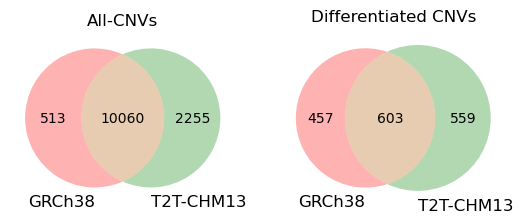

In [260]:
from matplotlib import pyplot as plt
import numpy as np
from matplotlib_venn import venn2_unweighted


plt.subplot(1, 2, 1) # row 1, col 2 index 1
venn2_unweighted(subsets = (513,2255,10060), set_labels = ('GRCh38', 'T2T-CHM13'), alpha = 0.3)
plt.title("All-CNVs")
plt.xlabel('X-axis ')
plt.ylabel('Y-axis ')

plt.subplot(1, 2, 2) # index 2
venn2(subsets = (457,559,603), set_labels = ('GRCh38', 'T2T-CHM13'), alpha = 0.3)
plt.title("Differentiated CNVs")
plt.xlabel('X-axis ')
plt.ylabel('Y-axis ')

plt.savefig('../plots/venn_diagram_shared_cnvs_among_assemblies_hprc.png', transparent=True)